# Formative 1: Time Series Data Pipeline — Task 1C: Modeling
**Group 1** | [COURSE NAME] | [SUBMISSION DATE]

**Notebook owner:** Elvin Cyubahiro
**Responsibility:** Feature engineering (cyclical encodings, multi-horizon lags, leakage-corrected rolling statistics), TimeSeriesSplit CV, XGBoost & Random Forest hyperparameter tuning, experiment comparison, and model serialization.

Part of a 4-notebook pipeline: `01_eda_preprocessing` → `02_modeling` → `03_databases` → `04_api_and_pipeline`.
Full end-to-end version: `00_full_pipeline.ipynb`. GitHub: [REPO URL]

**Output artifact:** `best_model.pkl` (consumed by notebook 04).
---

# Building a Pipeline for Time Series Data
## Power Consumption of Tétouan City, Morocco

**Dataset:** [Power Consumption of Tetouan City](https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption) — Kaggle / [UCI ML Repository](https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city)

**Description:** 52,416 observations recorded every 10 minutes across three distribution zones (Quads, Smir, Boussafou) in Tétouan, northern Morocco. Includes weather variables and solar diffuse flow measurements. Full year 2017.

The dataset is loaded programmatically using `kagglehub`, which handles authentication and caching automatically in Google Colab.

**Prediction Target:** Total power consumption (sum of all three zones)

---

### Contents
1. **Task 1** — Time-Series Preprocessing & Exploratory Analysis
2. **Task 2** — Database Design (SQL & MongoDB)
3. **Task 3** — CRUD Endpoints for Time-Series Queries
4. **Task 4** — Prediction / Forecast Script

## 1.1 Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')
sns.set_palette('deep')
print("Libraries loaded.")

Libraries loaded.


In [2]:
!pip install -q kagglehub

import kagglehub
import os, glob

# NOTE: kagglehub needs Kaggle API credentials to download.
# In Colab: Settings (gear icon, left sidebar) -> Secrets -> add KAGGLE_USERNAME and KAGGLE_KEY
#   (get these from kaggle.com/settings -> API -> Create New Token, opens a kaggle.json file
#    containing both values)
# Then uncomment the 3 lines below to load them into the environment:

# from google.colab import userdata
# os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
# os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

try:
    path = kagglehub.dataset_download("fedesoriano/electric-power-consumption")
    print("Downloaded to:", path)
    csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
    print("CSV files found:", csv_files)
    CSV_PATH = csv_files[0]
    print("Using:", CSV_PATH)
except Exception as e:
    print("kagglehub download failed:", e)
    print("Run the fallback cell below instead.")
    CSV_PATH = None

Using Colab cache for faster access to the 'electric-power-consumption' dataset.
Downloaded to: /kaggle/input/electric-power-consumption
CSV files found: ['/kaggle/input/electric-power-consumption/powerconsumption.csv']
Using: /kaggle/input/electric-power-consumption/powerconsumption.csv


In [3]:
import os
if 'CSV_PATH' not in dir() or not os.path.exists(CSV_PATH):
    print("Falling back to GitHub mirror (no Kaggle auth needed)...")
    CSV_PATH = 'powerconsumption.csv'
    !wget -q -O {CSV_PATH} "https://raw.githubusercontent.com/sunny2309/datasets/master/Tetuan%20City%20power%20consumption.csv"
    print("Downloaded to:", CSV_PATH)
else:
    print("kagglehub download already succeeded, skipping fallback.")

kagglehub download already succeeded, skipping fallback.


In [4]:
df = pd.read_csv(CSV_PATH)

# Clean column names defensively (strip whitespace, handle BOM)
df.columns = [str(c).strip().replace('\ufeff', '') for c in df.columns]
print("Raw columns:", list(df.columns))

# Find the datetime column regardless of exact name/case
dt_col = next((c for c in df.columns if c.lower() in
               ('datetime', 'date_time', 'date', 'timestamp')), df.columns[0])
print("Detected datetime column:", dt_col)

df[dt_col] = pd.to_datetime(df[dt_col])
df = df.rename(columns={dt_col: 'DateTime'}).set_index('DateTime').sort_index()

# Sanity check: dataset should have exactly 8 remaining feature columns
assert df.shape[1] == 8, "Expected 8 feature columns, got {}: {}".format(df.shape[1], list(df.columns))

df.columns = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows',
              'DiffuseFlows', 'Zone1', 'Zone2', 'Zone3']
df['TotalConsumption'] = df['Zone1'] + df['Zone2'] + df['Zone3']

print("Shape:", df.shape)
print("Range:", df.index.min(), "to", df.index.max())
df.head()

Raw columns: ['Datetime', 'Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']
Detected datetime column: Datetime
Shape: (52416, 9)
Range: 2017-01-01 00:00:00 to 2017-12-30 23:50:00


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,Zone1,Zone2,Zone3,TotalConsumption
DateTime,,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,70425.53544
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,69320.84387
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,67803.22193
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,65489.23209
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,63650.44627


> **Section lead:** Elvin Cyubahiro — feature engineering, model experiments, hyperparameter tuning, and experiment comparison (see commit history in the repository).


## Part C: Model Training

XGBoost vs Random Forest on hourly-resampled data with engineered features.

### C.1 Feature Engineering

In [16]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib

hourly = df.resample('1h').mean()
feat = hourly.copy()

# Cyclical time
feat['Hour_sin']      = np.sin(2*np.pi*feat.index.hour/24)
feat['Hour_cos']      = np.cos(2*np.pi*feat.index.hour/24)
feat['Month_sin']     = np.sin(2*np.pi*feat.index.month/12)
feat['Month_cos']     = np.cos(2*np.pi*feat.index.month/12)
feat['DoW_sin']       = np.sin(2*np.pi*feat.index.dayofweek/7)
feat['DoW_cos']       = np.cos(2*np.pi*feat.index.dayofweek/7)
feat['IsWeekend']     = (feat.index.dayofweek >= 5).astype(int)

# Lags
for lag in [1,2,3,6,12,24,48,168]:
    feat['Lag_{}h'.format(lag)] = feat['TotalConsumption'].shift(lag)

# Rolling stats
for w in [6,12,24,48,168]:
    feat['MA_{}h'.format(w)]  = feat['TotalConsumption'].shift(1).rolling(w).mean()
    feat['Std_{}h'.format(w)] = feat['TotalConsumption'].shift(1).rolling(w).std()

# Interactions
feat['Temp_sq']       = feat['Temperature']**2
feat['Temp_x_Hum']    = feat['Temperature'] * feat['Humidity']

feat = feat.dropna()
print("Feature matrix:", feat.shape)

Feature matrix: (8568, 36)


### C.2 Train / Test Split

In [17]:
exclude = ['Zone1','Zone2','Zone3','TotalConsumption']
feature_cols = [c for c in feat.columns if c not in exclude]

X = feat[feature_cols]; y = feat['TotalConsumption']
split = int(len(X)*0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Train:", X_train.shape, " | ", X_train.index.min().date(), "->", X_train.index.max().date())
print("Test: ", X_test.shape, " | ", X_test.index.min().date(), "->", X_test.index.max().date())

Train: (6854, 32)  |  2017-01-08 -> 2017-10-20
Test:  (1714, 32)  |  2017-10-20 -> 2017-12-30


### C.3 Experiment 1 — XGBoost (3 configs)

In [18]:
tscv = TimeSeriesSplit(n_splits=3)

xgb_cfgs = {
    'XGB_v1': dict(n_estimators=200, max_depth=4, learning_rate=0.1,
                   subsample=0.8, colsample_bytree=0.8),
    'XGB_v2': dict(n_estimators=300, max_depth=6, learning_rate=0.1,
                   subsample=0.8, colsample_bytree=0.8),
    'XGB_v3': dict(n_estimators=500, max_depth=8, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8),
}

xgb_res = {}
for name, params in xgb_cfgs.items():
    m = XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0)
    cv = []
    for ti, vi in tscv.split(X_train):
        m.fit(X_train.iloc[ti], y_train.iloc[ti])
        cv.append(mean_absolute_error(y_train.iloc[vi], m.predict(X_train.iloc[vi])))
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    xgb_res[name] = dict(model=m, pred=p, params=params,
        cv_mae=np.mean(cv),
        rmse=np.sqrt(mean_squared_error(y_test, p)),
        mae=mean_absolute_error(y_test, p),
        r2=r2_score(y_test, p))
    print("{}: CV MAE={:,.0f}  Test RMSE={:,.0f}  R2={:.4f}".format(
        name, xgb_res[name]['cv_mae'], xgb_res[name]['rmse'], xgb_res[name]['r2']))

best_xgb = min(xgb_res.values(), key=lambda x: x['mae'])

XGB_v1: CV MAE=2,466  Test RMSE=1,835  R2=0.9828
XGB_v2: CV MAE=2,477  Test RMSE=1,796  R2=0.9836
XGB_v3: CV MAE=2,524  Test RMSE=1,839  R2=0.9828


### C.4 Experiment 2 — Random Forest (3 configs)

In [19]:
rf_cfgs = {
    'RF_v1': dict(n_estimators=200, max_depth=10, min_samples_split=5, min_samples_leaf=2),
    'RF_v2': dict(n_estimators=300, max_depth=15, min_samples_split=5, min_samples_leaf=2),
    'RF_v3': dict(n_estimators=500, max_depth=20, min_samples_split=10,min_samples_leaf=4),
}

rf_res = {}
for name, params in rf_cfgs.items():
    m = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    cv = []
    for ti, vi in tscv.split(X_train):
        m.fit(X_train.iloc[ti], y_train.iloc[ti])
        cv.append(mean_absolute_error(y_train.iloc[vi], m.predict(X_train.iloc[vi])))
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    rf_res[name] = dict(model=m, pred=p, params=params,
        cv_mae=np.mean(cv),
        rmse=np.sqrt(mean_squared_error(y_test, p)),
        mae=mean_absolute_error(y_test, p),
        r2=r2_score(y_test, p))
    print("{}: CV MAE={:,.0f}  Test RMSE={:,.0f}  R2={:.4f}".format(
        name, rf_res[name]['cv_mae'], rf_res[name]['rmse'], rf_res[name]['r2']))

best_rf = min(rf_res.values(), key=lambda x: x['mae'])

RF_v1: CV MAE=2,506  Test RMSE=2,112  R2=0.9773
RF_v2: CV MAE=2,478  Test RMSE=2,054  R2=0.9785
RF_v3: CV MAE=2,475  Test RMSE=2,061  R2=0.9784


### C.5 Experiment Comparison Table

In [20]:
rows = []
for name, r in {**xgb_res, **rf_res}.items():
    rows.append(dict(Config=name,
        CV_MAE="{:,.0f}".format(r['cv_mae']),
        Test_RMSE="{:,.0f}".format(r['rmse']),
        Test_MAE="{:,.0f}".format(r['mae']),
        Test_R2="{:.4f}".format(r['r2'])))
table = pd.DataFrame(rows)
print("=" * 75)
print("EXPERIMENT COMPARISON")
print("=" * 75)
print(table.to_string(index=False))
print("=" * 75)

if best_xgb['r2'] >= best_rf['r2']:
    best_name = 'XGBoost'; best_model = best_xgb['model']; best_pred = best_xgb['pred']
else:
    best_name = 'Random Forest'; best_model = best_rf['model']; best_pred = best_rf['pred']
print()
print("Best model:", best_name, "  R2 =", "{:.4f}".format(max(best_xgb['r2'], best_rf['r2'])))

EXPERIMENT COMPARISON
Config CV_MAE Test_RMSE Test_MAE Test_R2
XGB_v1  2,466     1,835    1,339  0.9828
XGB_v2  2,477     1,796    1,294  0.9836
XGB_v3  2,524     1,839    1,322  0.9828
 RF_v1  2,506     2,112    1,469  0.9773
 RF_v2  2,478     2,054    1,416  0.9785
 RF_v3  2,475     2,061    1,415  0.9784

Best model: XGBoost   R2 = 0.9836


### C.6 Prediction Visualization

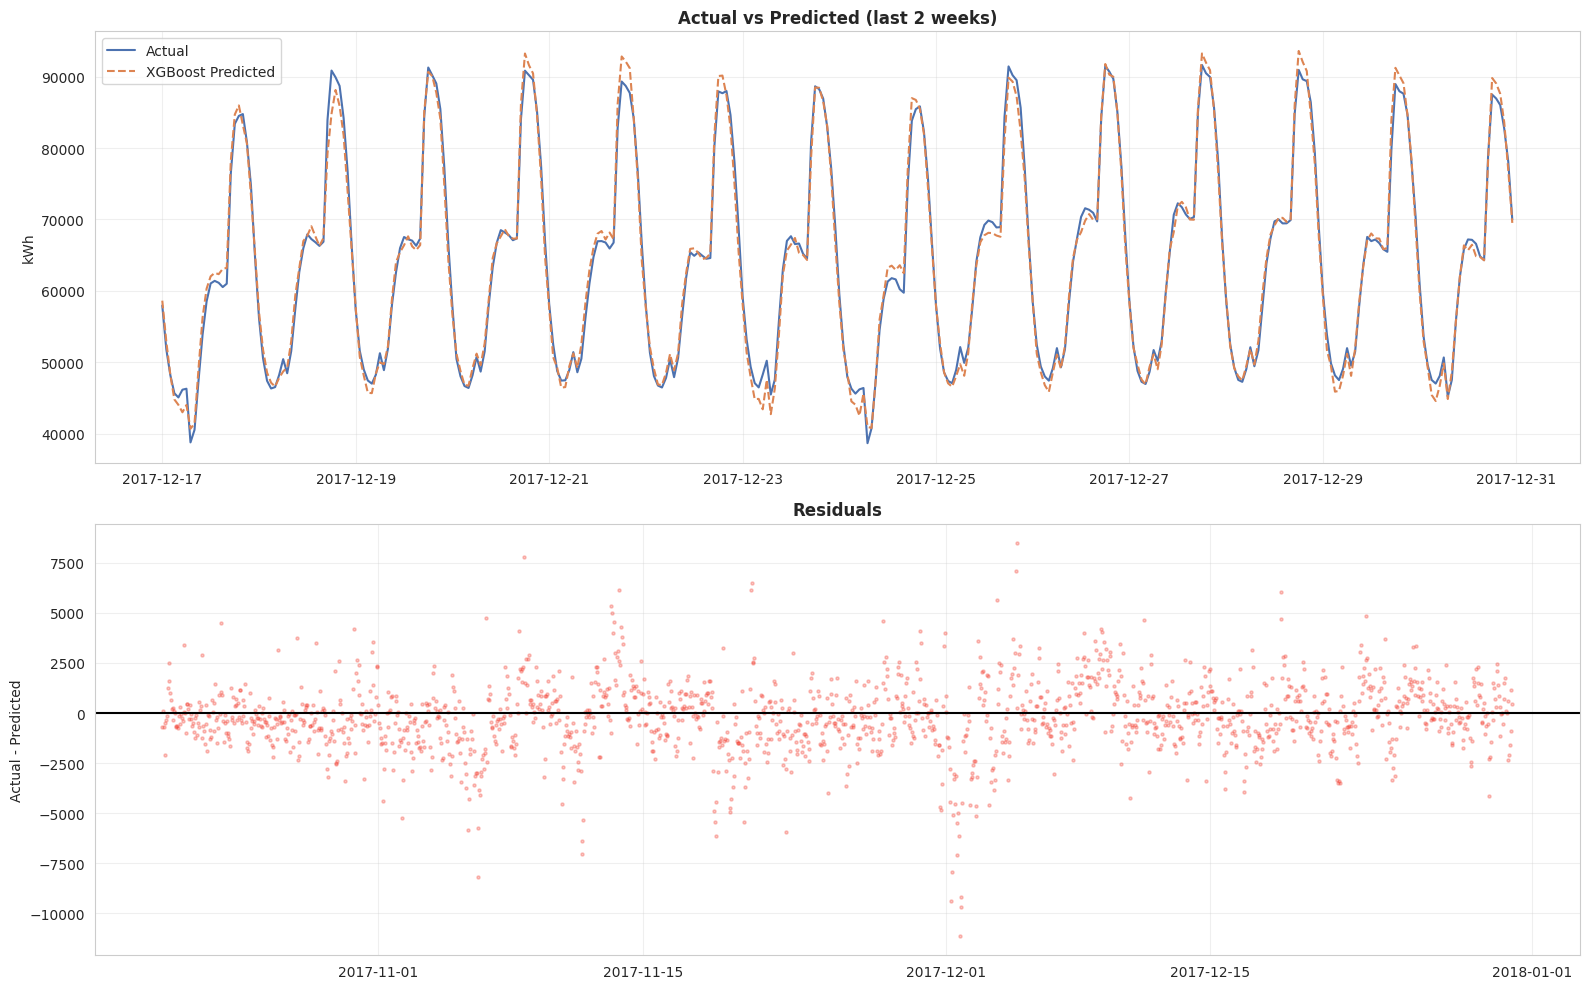

Residual mean: -208.8   std: 1783.7


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

n = 24*14
axes[0].plot(y_test.index[-n:], y_test.values[-n:], label='Actual', lw=1.5)
axes[0].plot(y_test.index[-n:], best_pred[-n:], label=best_name+' Predicted', lw=1.5, ls='--')
axes[0].set_title('Actual vs Predicted (last 2 weeks)', fontweight='bold')
axes[0].set_ylabel('kWh'); axes[0].legend()

resid = y_test.values - best_pred
axes[1].scatter(y_test.index, resid, alpha=0.3, s=5, color='#F44336')
axes[1].axhline(0, color='black', lw=1.5)
axes[1].set_title('Residuals', fontweight='bold'); axes[1].set_ylabel('Actual - Predicted')
plt.tight_layout(); plt.show()
print("Residual mean: {:.1f}   std: {:.1f}".format(resid.mean(), resid.std()))

### C.7 Feature Importance

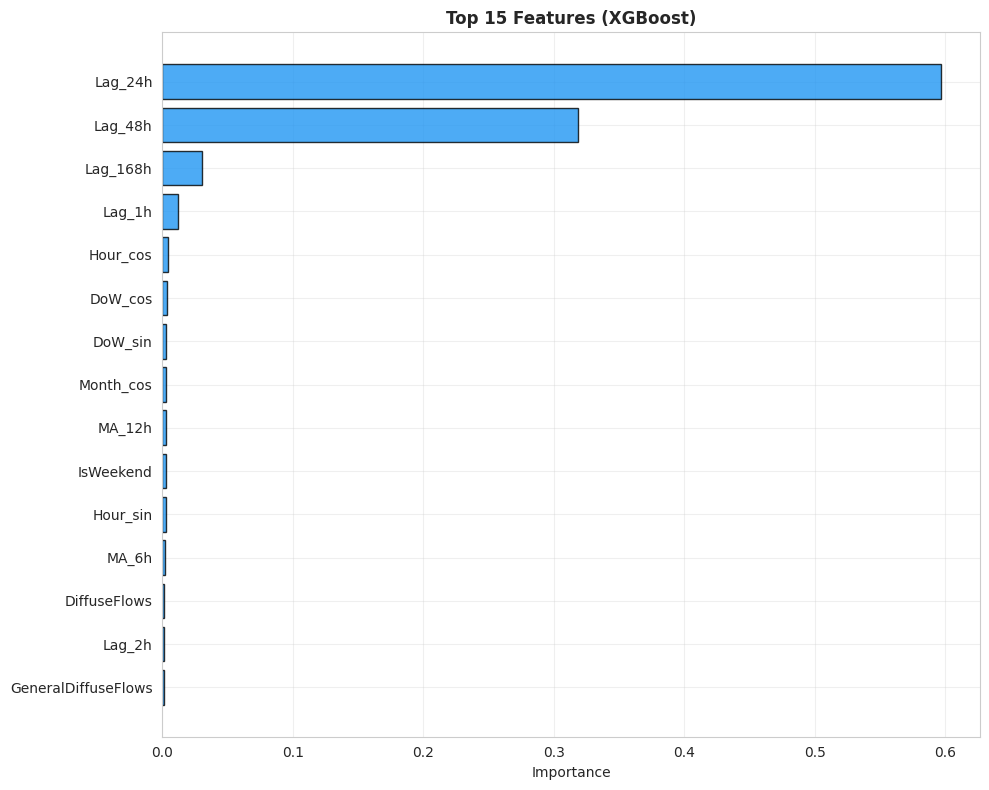

In [22]:
imp = pd.DataFrame({'Feature': feature_cols,
                     'Importance': best_model.feature_importances_})
imp = imp.sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(imp['Feature'], imp['Importance'], color='#2196F3', edgecolor='black', alpha=0.8)
ax.set_title('Top 15 Features ({})'.format(best_name), fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

**Interpretation:** Lag features (especially lag-1h, lag-24h) and rolling averages dominate, confirming recent history is the strongest predictor. Weather adds secondary value.

### C.8 Save Model

In [23]:
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
print("Saved best_model.pkl and feature_cols.pkl")

Saved best_model.pkl and feature_cols.pkl
